In [33]:
# Importowanie ważnych bibliotek
import torch
import torch.nn as nn # nn to w skrócie neural network
import torch.optim as optim
import torchvision
from torchvision import transforms, models
import torch.utils.data as data
from tqdm.notebook import tqdm # pozwala na wyświetlenie progress baru
import matplotlib.pyplot as plt # wizualizacja
import numpy as np
import medmnist
from medmnist import INFO
import sys
import os

In [34]:
# Setup urządzenia
# karta graficzna CUDA jest x50 szybsza
if torch.cuda.is_available():
    count = torch.cuda.device_count()
    device = torch.device("cuda")
    print(f"GPU count: {count}.")
else:
    device = torch.device("cpu")

print(f"Setup Complete. Using device: {device}.")

Setup Complete. Using device: cpu.


100%|██████████████████████████████████████████████████████████████████████████████| 35.5M/35.5M [00:07<00:00, 4.84MB/s]


Amount of training data: 11959
Classes to learn: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


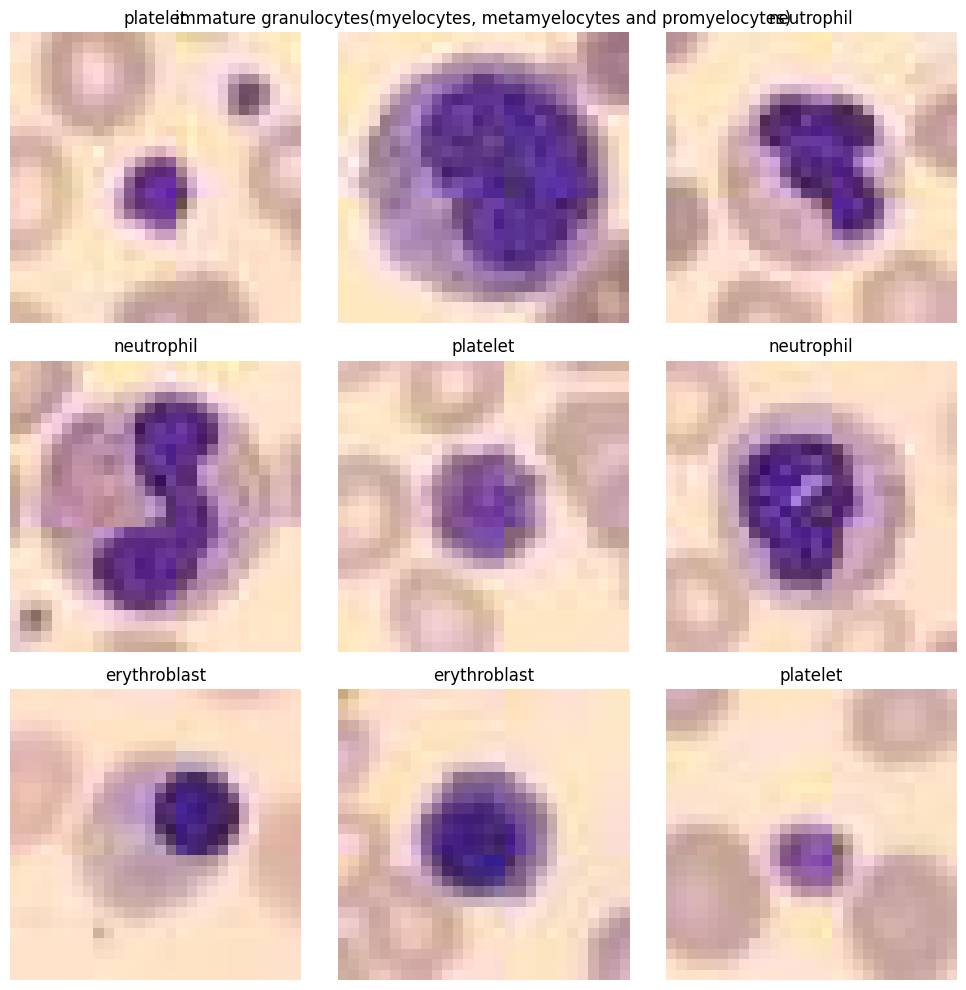

In [35]:
# 1. Setup the dataset details
data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class']) # komenda getattr(klasa, wartość). tablica['nazwa']. Wzięto od info.py. 
# DataClass bierze wartość od bloomnist

# 2. Pobierz dane do treningu
# Ta komenda stworzy też folder 'data'
train_dataset = DataClass(split='train', download=True, root='../data' )
print(f"Amount of training data: {len(train_dataset)}")
# 3. Spojrzenie na etykiety, co AI próbuje się uczyć
print("Classes to learn:", info['label'])

# stworzenie pustej ramki 10x10
fig = plt.figure(figsize=(10, 10))
# 4. Pokaz 9 przykładowych obrazów komórek
for i in range(9):
    img, label = train_dataset[i]
    ax = fig.add_subplot(3, 3, i + 1) # ax od Axes # Podzielenie tablicy na 3x3. i + 1 mówi o tym aby przeskoczyć o jeden obraz iteracyjnie
    # konwert etykiety na string
    label_name = info['label'][str(label[0])] 
    ax.imshow(img) # imshow od skrótu imshow. W okienku ax inputować obrazek (img)
    ax.set_title(label_name) # ustawienie tytułu obrazka
    ax.axis('off') # wyłącza widoczność osi x i y 
# ta komenda automatycznie ustawia ciasny layout
plt.tight_layout()
plt.show()


In [36]:
# Normalizacja danych
# 1. Wybierz rozmiar
size = 64 

# 2. Normalizacja w ResNet ( Residual Network) 
resnet_transform = transforms.Compose([ # Data Augmentation (sztuczne powiększenie obrazu) i normalizacja. transforms.Compose komponuje kroki które podejmie w każdym kroku
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # randomalizacja obrazków, obroty horyzontalne i rotacje. Zapobiega overfitting
    transforms.ToTensor(), # zamienia zwykły obrazek na taki zrozumiały dla karty graficznej czyli tensory. tensory to specjalne tablice liczb
    # Te wartości były oryginalnie trenowane na ImageNet, więc powinniśmy "przesuwać" te wartości bardziej do naszych danych
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # mean to średnia, std to standardowe odchylenie
])

# 3. Ładuj NATIVE 64x64 versions
train_dataset = DataClass(split='train', transform=resnet_transform, download=True, size=size)
val_dataset = DataClass(split='val', transform=resnet_transform, download=True, size=size)
test_dataset = DataClass(split='test', transform=resnet_transform, download=True, size=size)

train_loader = data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True) # data jest od torch.utils.data. parametr dataset definiuje gdzie wziąć dane. batch_size definiuje ile próbek na jedną serię. shuffle, czy przetasować dane.
val_loader = data.DataLoader(dataset=val_dataset, batch_size=64, shuffle=False) # W tym nie tasować, sprawdzamy tylko wynik naszego owocu, wynik taki sam
test_loader = data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Loaded Native {size}x{size} MedMNIST+ data.")

Loaded Native 64x64 MedMNIST+ data.


In [38]:
# Sprawdzenie rozmiaru
# Bierze jeden element z train_loadera
images, labels = next(iter(train_loader)) # dwie parametry, bo potrzebne jest etykieta do uczenia się obrazka

print(f"Image batch shape: {images.shape}") 
# Oczekiwane: [64, 3, 64, 64] -> [Batch Size, Channels(RGB), Height, Width]

print(f"Label batch shape: {labels.shape}")
# Oczekiwane: [64, 1]

Image batch shape: torch.Size([64, 3, 64, 64])
Label batch shape: torch.Size([64, 1])


In [40]:
# Ładowanie modelu w pre-trained weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


# wyciągnij ilość inputu
num_ftrs = model.fc.in_features 

# syntax: nn.Linear(in_features, out_features), gdzie in_features i out_features to liczby
model.fc = nn.Linear(num_ftrs, 8) # num_ftrs definiuje ilość oczekiwanego inputu, tych cech z obrazka, output jest 8, tych klas komórek

model = model.to(device)

# Mniejszy learning rate (lr)
# Bo model jest już wystarczająco mądry
optimizer = optim.Adam(model.parameters(), lr=0.0001) 
# factor czyli potęga, w tym przypadku zmniejszy 10krotnie po dwóch nieudanych epokach
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.1)

# W CrossEntropyLoss są dwa funkcje softmax( konwert z liczb na procenty) i log loss ( oblicza błąd na podstawie różnicy procentu, a prawdą)
criterion = nn.CrossEntropyLoss()
# print(model), aby spojrzeć na model
# https://www.learnpytorch.io/, nauczenie się podstaw

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Trening
best_acc = 0.0
num_epochs = 10 

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze().long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long()
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1} | Val Acc: {val_acc:.2f}%")
    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'resnet_blood_best.pth')
        print("--> Saved New Best ResNet Model!")

print(f"Transfer Learning Finished. Best Accuracy: {best_acc:.2f}%")

Epoch 1:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 1 | Val Acc: 96.26%
--> Saved New Best ResNet Model!


Epoch 2:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 2 | Val Acc: 97.31%
--> Saved New Best ResNet Model!


Epoch 3:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch 8 | Val Acc: 98.95%


Epoch 9:   0%|          | 0/187 [00:00<?, ?it/s]

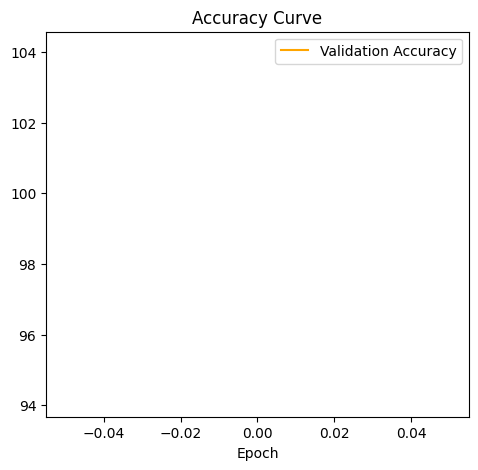

In [11]:
plt.figure(figsize=(12, 5))

# # Plot Loss
# plt.subplot(1, 2, 1)
# plt.plot(train_losses, label='Training Loss')
# plt.title('Loss Curve')
# plt.xlabel('Epoch')
# plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(best_acc, label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.5759914].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.62

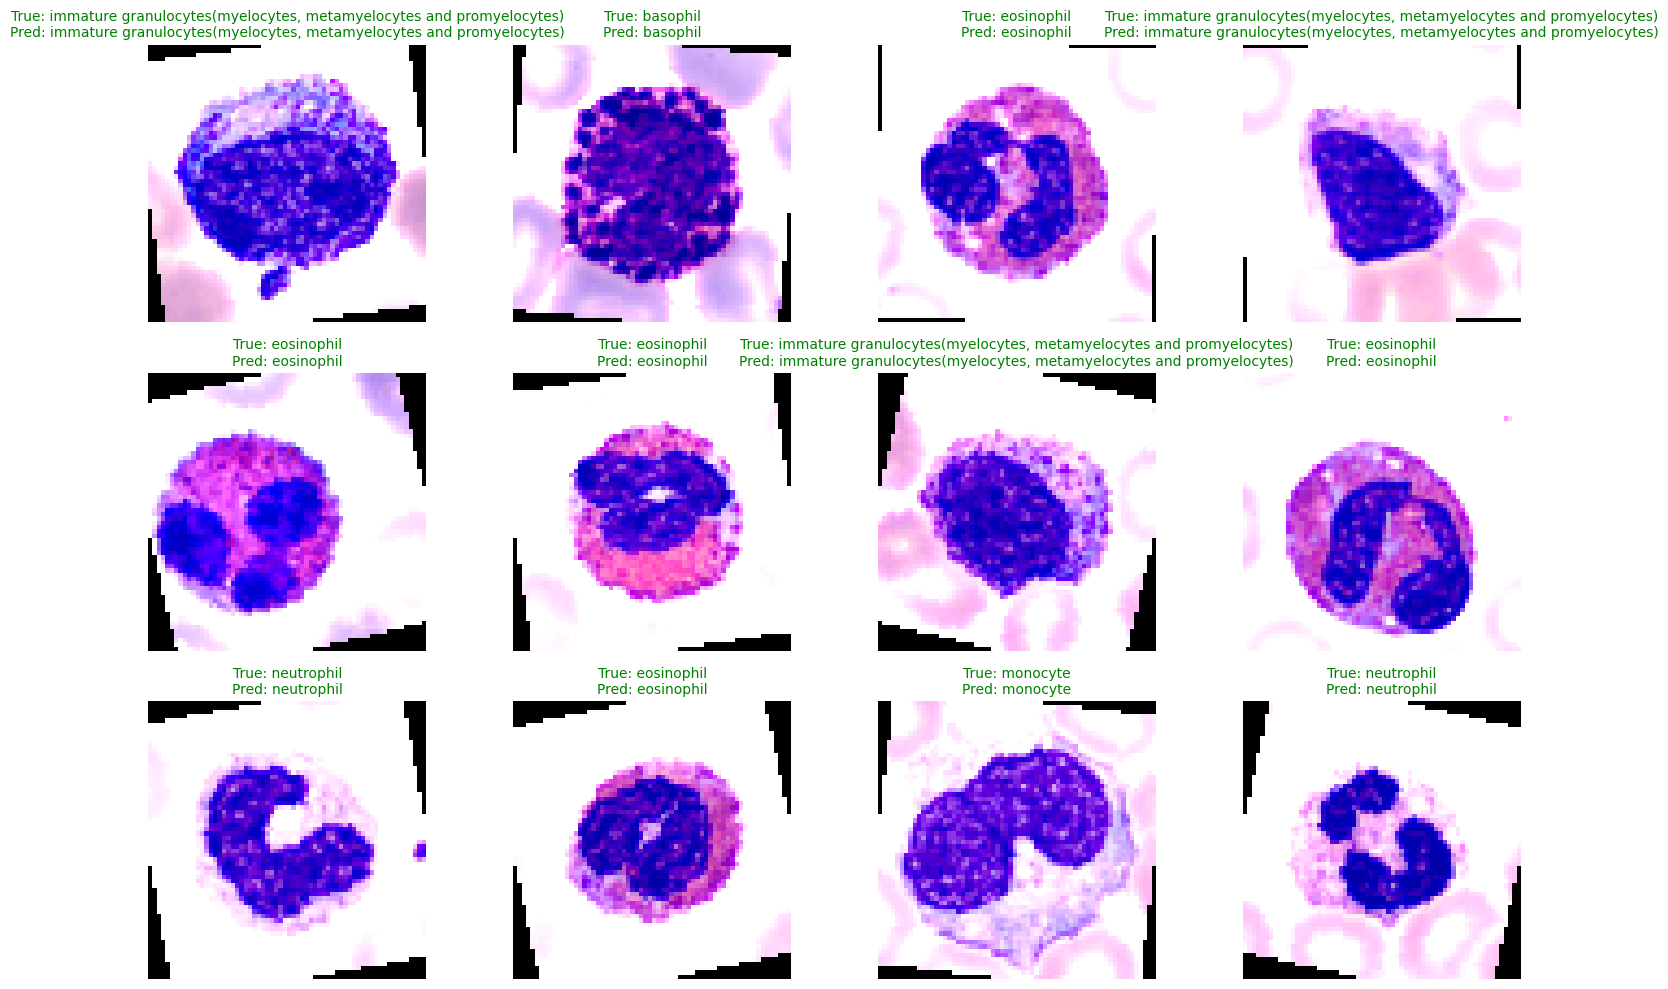

In [12]:
import torch
import numpy as np

def visualize_results(model, test_loader, info):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    
    images = images.cpu()
    labels = labels.cpu().numpy()
    predicted = predicted.cpu().numpy()
    
    plt.figure(figsize=(15, 10))
    for i in range(12): # Popatrz na pierwsze 12 obrazów
        ax = plt.subplot(3, 4, i + 1)
        
        # Nie normalizuj obrazu dla pokazu
        img = images[i].permute(1, 2, 0) * 0.5 + 0.5 
        
        true_name = info['label'][str(labels[i][0])]
        pred_name = info['label'][str(predicted[i])]
        
        color = 'green' if true_name == pred_name else 'red'
        
        plt.imshow(img)
        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# odtwórz wizualizację
visualize_results(model, test_loader, info)

In [13]:
# ładowanie najlepszego modelu
model.load_state_dict(torch.load('resnet_blood_best.pth'))
model.eval()

# testowanie modelu
correct = 0
total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze().long()
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

final_acc = 100 * correct / total
print(f"ULTIMATE TEST ACCURACY: {final_acc:.2f}%")

ULTIMATE TEST ACCURACY: 98.07%


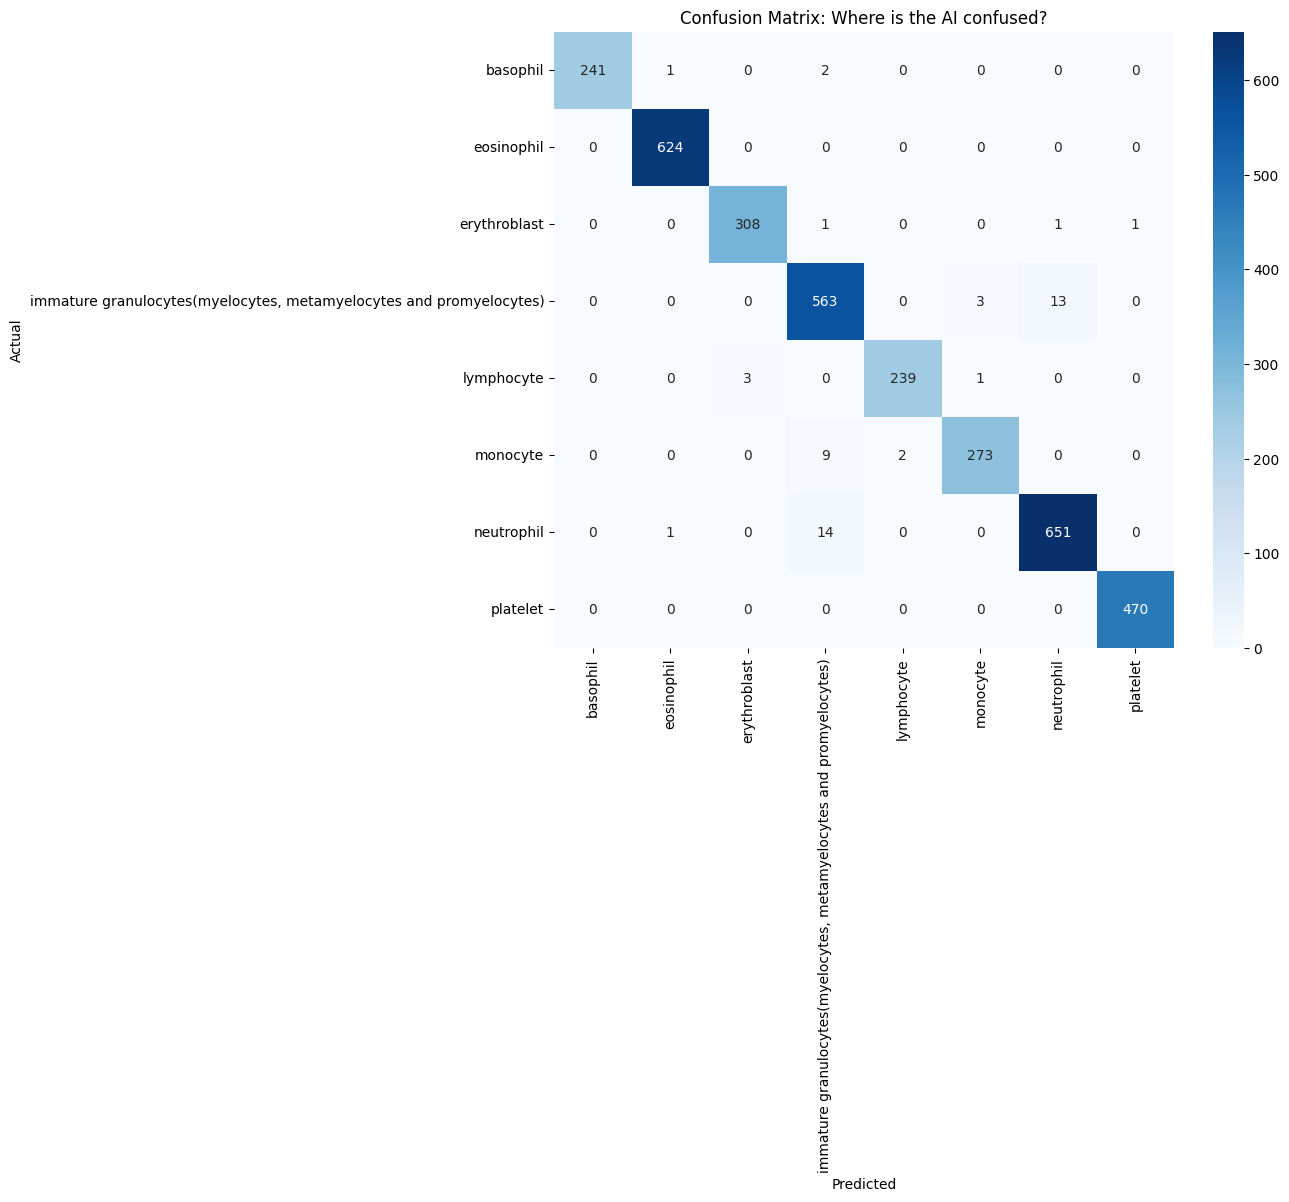

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.numpy().flatten())

# Stworzenie matrycy
conf_mat = confusion_matrix(all_labels, all_preds)

# 3. Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=info['label'].values(),
            yticklabels=info['label'].values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where is the AI confused?')
plt.show()

Original Image Size: 197x197
Finished! Created 9 slices in the 'sliced_cells' folder.


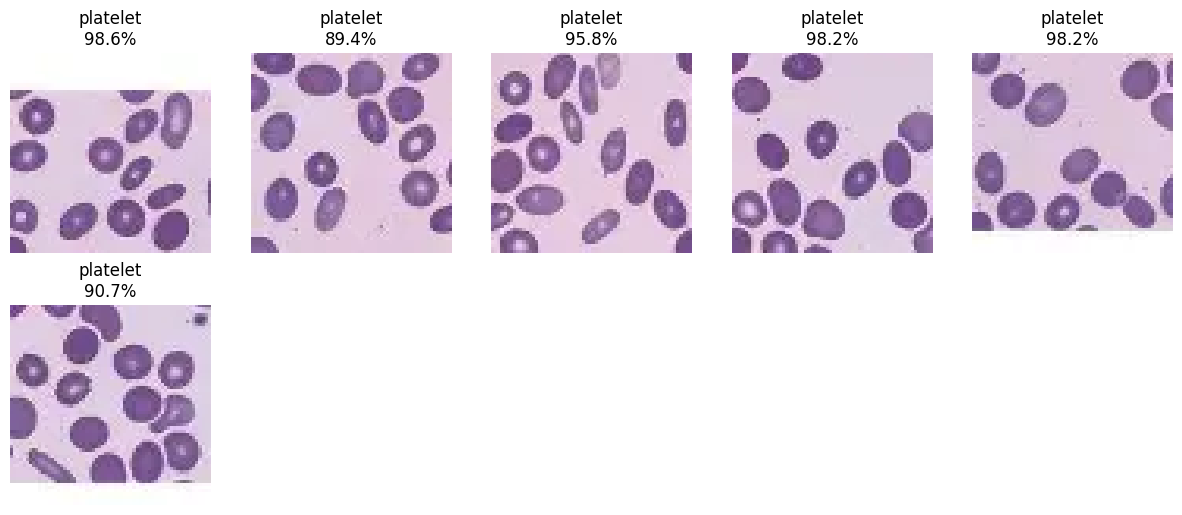

In [19]:
# Pokaż obraz wycięty na mniejsze kawałki

sys.path.append('../src')

# Import your new logic
from inference import slice_and_detect, show_detections

# Run it on your new image
results = slice_and_detect('../inference_samples/blood_smear_test.webp', model, resnet_transform, info)

# See the results
show_detections(results)